# Loading Required Libraries and Dataset Files

In [3]:
#Matplotlib is a Python library primarily used for generating and displaying plots and graphs.
#It provides tools that help visualize data effectively for analysis and presentation.
import matplotlib.pyplot as plt

#This import comes from the matplotlib package and is specifically used for reading image files.
#It will be useful later when loading and displaying the confusion matrix image produced by the model.
import matplotlib.image as mpimg

#Pandas is a widely used Python library for working with structured datasets.
#It offers powerful tools for data analysis, cleaning, exploration, and manipulation.
import pandas as pd

#The following import enables access to additional Google Colab features.
#Mounting the drive allows us to read from and write files directly to our Google Drive storage.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
#The command below executes a shell instruction to install a required package in the environment.
#Specifically, it installs or upgrades the ultralytics library which provides access to the YOLOv26 model.
!pip install ultralytics --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.2 MB/s eta 0:00:00


# Building and Training the Model

In [6]:
#The import statement below gives us access to the model implementations provided by ultralytics.
#Here, we specifically import the YOLO class which is used for object detection tasks.
from ultralytics import YOLO

#The line below initializes the first YOLO model instance.
#We are using the yolov26n weights because this variant is optimized to be lightweight and fast.
modeladamw = YOLO('yolo26n.pt')

#This line creates a second YOLO model instance using the same pretrained weights.
#It will be used separately to experiment with another set of parameters.
modelsgd = YOLO('yolo26n.pt')

#The line below creates a third YOLO model object with the same base weights.
#This instance allows us to test a different configuration during training.
modelauto = YOLO('yolo26n.pt')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [7]:
#The command below starts the training process using the prepared dataset.
#We also define several hyperparameters to control how the model learns and performs.
modeladamw.train(

    #This argument tells the model where the dataset configuration file is located.
    #The data.yaml file contains the paths to images, labels, and other dataset metadata.
    data='/content/drive/MyDrive/SA1_PASTIU.v4i.yolo26/data.yaml',

    #This parameter sets how many complete passes over the dataset the model will perform.
    #Higher epoch counts allow more learning but may increase training time.
    epochs=25,

    #This defines the input image resolution that will be fed into the model.
    #All images are resized to 640x640 pixels during training.
    imgsz=640,

    #This value determines how many images are processed in each training batch.
    #Smaller batch sizes use less memory but may train more slowly.
    batch=4,

    #This specifies which optimization algorithm will update the model weights.
    #AdamW is used here because it combines adaptive learning with weight regularization.
    optimizer='AdamW',

    #This sets the initial learning rate, which controls how large each weight update step is.
    #A properly tuned learning rate helps stabilize and speed up training.
    lr0=0.01

)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/SA1_PASTIU.v4i.yolo26/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x796ca6279940>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [8]:
#The instruction below begins training for the second model using the selected dataset.
#We again define hyperparameters to control learning behavior and overall model performance.
modelsgd.train(

    #This argument points the model to the dataset configuration file location.
    #The data.yaml file contains the paths to images, labels, and class information.
    data='/content/drive/MyDrive/SA1_PASTIU.v4i.yolo26/data.yaml',

    #This sets the number of full training cycles over the dataset.
    #Increasing epochs allows the model more opportunities to learn patterns.
    epochs=30,

    #This defines the resolution that input images will be resized to during training.
    #All images are standardized to 640x640 pixels.
    imgsz=640,

    #This determines how many images are processed together in one batch.
    #A larger batch size can speed up training but requires more memory.
    batch=20,

    #This selects the optimizer used to update model weights.
    #SGD (Stochastic Gradient Descent) updates weights based on the computed loss gradients.
    optimizer='SGD',

    #This sets the initial learning rate controlling how big each weight update step is.
    #Lower values typically provide more stable but slower learning.
    lr0=0.001
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=20, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/SA1_PASTIU.v4i.yolo26/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_mask=True,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x796c3c1368a0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [9]:
#The command below starts training for the third model using the same dataset.
#Different hyperparameters are provided here to observe how they affect performance.
modelauto.train(

    #This parameter specifies the path to the dataset configuration file.
    #The data.yaml file tells the model where to find images, labels, and class info.
    data='/content/drive/MyDrive/SA1_PASTIU.v4i.yolo26/data.yaml',

    #This sets how many full passes over the dataset will be performed during training.
    #More epochs allow the model additional time to learn from the data.
    epochs=40,

    #This defines the input image size used by the model.
    #Images are resized to a standard 640x640 resolution.
    imgsz=640,

    #This controls how many images are processed per batch.
    #A value of -1 lets the framework automatically choose the batch size based on available resources.
    batch=-1,

    #This selects the optimizer configuration for training.
    #Using 'auto' allows YOLO to automatically determine the most suitable optimizer.
    optimizer='auto',

    #This sets the starting learning rate, which influences how quickly weights are updated.
    #A smaller value like this promotes more gradual and stable learning.
    lr0=0.0001
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/SA1_PASTIU.v4i.yolo26/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tru

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x796c4c5b5fa0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

# Evaluation Metrics and Result Visualizations

In [10]:
#The lines below run the validation phase for each trained model.
#This process evaluates the models using the validation dataset and returns their performance metrics.
metrics1 = modeladamw.val()


#This executes validation for the second model instance.
#The resulting metrics summarize how well the model performed on unseen validation data.
metrics2 = modelsgd.val()

#This performs the validation step for the third model.
#It outputs evaluation statistics that can be used for comparison across models.
metrics3 = modelauto.val()

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,616 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 14.4±5.7 MB/s, size: 37.3 KB)
val: Scanning /content/drive/MyDrive/SA1_PASTIU.v4i.yolo26/valid/labels.cache... 78 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 78/78 18.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.1it/s 4.4s
                   all         78        234      0.717      0.856      0.759      0.561
                   Bus          1          1      0.186          1      0.332      0.298
                   Car         67        149      0.927      0.933      0.974      0.811
            Motorcycle         43         60      0.922       0.65      0.834      0.427
                 Truck         21         24      0.835      0.843      0.895      0.708
Speed: 13.3ms preprocess, 1

In [11]:
metrics1 = modeladamw.val()

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.6±0.3 ms, read: 16.9±5.0 MB/s, size: 35.3 KB)
val: Scanning /content/drive/MyDrive/SA1_PASTIU.v4i.yolo26/valid/labels.cache... 78 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 78/78 23.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.4it/s 3.5s
                   all         78        234      0.717      0.856      0.759      0.561
                   Bus          1          1      0.186          1      0.332      0.298
                   Car         67        149      0.927      0.933      0.974      0.811
            Motorcycle         43         60      0.922       0.65      0.834      0.427
                 Truck         21         24      0.835      0.843      0.895      0.708
Speed: 7.5ms preprocess, 9.6ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to /content/ru

In [12]:
#The code below creates a pandas DataFrame that summarizes the hyperparameter settings
#used for each of the trained models.
hyperparams_table = pd.DataFrame({

    #This column labels each model configuration for easy identification.
    #It lists the three model variants evaluated in this experiment.
    "Model": ["Model 1", "Model 2", "Model 3"],

    #This column records the number of training epochs assigned to each model.
    #These values indicate how many full passes over the dataset were performed.
    "Epochs": [25, 30, 40],

    #This column shows the image resolution used during training.
    #All models used the same fixed input size of 640 pixels.
    "Image Size": [640, 640, 640],

    #This column specifies which optimizer was applied for each model.
    #Different optimizers were tested to compare training behavior.
    "Optimizer": ["AdamW", "SGD", "auto"],

    #This column lists the batch size used for each training run.
    #The value -1 indicates automatic batch size selection.
    "Batch Size": [4, 20, -1],

    #This column displays the initial learning rate assigned to each model.
    #Learning rate controls how aggressively the model updates its weights.
    "Learning Rate": [0.01, 0.001, 0.0001]
})

#The line below outputs the DataFrame so the hyperparameter summary table is visible.
#This helps in quickly reviewing and comparing the configurations used.
hyperparams_table

,Model,Epochs,Image Size,Optimizer,Batch Size,Learning Rate
0,Model 1,25,640,AdamW,4,0.0100
1,Model 2,30,640,SGD,20,0.0010
2,Model 3,40,640,auto,-1,0.0001


In [13]:
#The code below builds a pandas DataFrame that summarizes the evaluation results
#obtained from each trained model after the validation phase.
metrics_table = pd.DataFrame({

    #This column identifies each model included in the comparison.
    #It labels the three trained model configurations.
    "Model": ["Model 1", "Model 2", "Model 3"],

    #This column records the mAP@50 scores extracted from the validation metrics.
    #The values are pulled directly from the metrics objects created earlier.
    "mAP50": [metrics1.box.map50, metrics2.box.map50, metrics3.box.map50],

    #This column contains the precision values for each model.
    #Precision reflects how many predicted detections were actually correct.
    "Precision": [metrics1.box.mp, metrics2.box.mp, metrics3.box.mp],

    #This column stores the recall values for each model.
    #Recall measures how many true objects were successfully detected.
    "Recall": [metrics1.box.mr, metrics2.box.mr, metrics3.box.mr],

    #This column computes the F1 Score using the harmonic mean of precision and recall.
    #It provides a balanced metric that considers both false positives and false negatives.
    "F1 Score": [
        2 * (metrics1.box.mp * metrics1.box.mr) / (metrics1.box.mp + metrics1.box.mr),
        2 * (metrics2.box.mp * metrics2.box.mr) / (metrics2.box.mp + metrics2.box.mr),
        2 * (metrics3.box.mp * metrics3.box.mr) / (metrics3.box.mp + metrics3.box.mr)
    ]

})

#The line below displays the completed metrics table in the output.
#This allows quick comparison of model performance across key evaluation metrics.
metrics_table

,Model,mAP50,Precision,Recall,F1 Score
0,Model 1,0.758686,0.717362,0.856355,0.780721
1,Model 2,0.598040,0.769030,0.552038,0.642713
2,Model 3,0.911802,0.578468,0.946183,0.717983


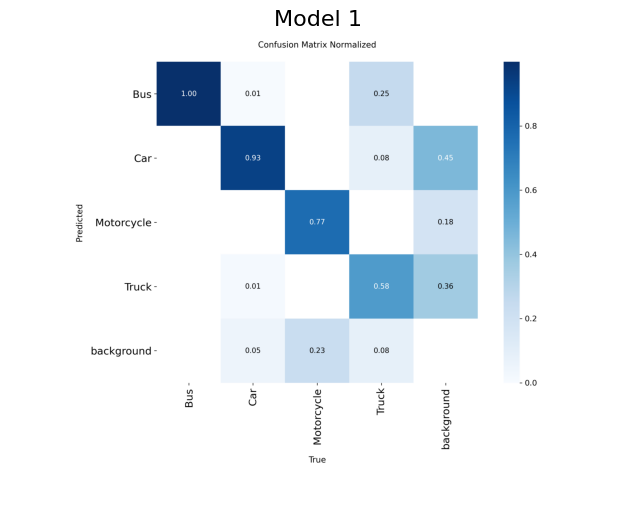

In [14]:
#The line below defines a variable that stores the file path of the confusion matrix image.
#This image is automatically produced by YOLO after the training process completes.
img_path1 = '/content/runs/detect/train/confusion_matrix_normalized.png'

#The line below reads the image file and converts it into an array format.
#This step prepares the image so it can be rendered using matplotlib.
img1 = mpimg.imread(img_path1)

#The line below initializes a new plotting figure.
#Here we explicitly set the figure size to control the display dimensions.
plt.figure(figsize=(8,6))

#The line below renders the loaded image onto the plotting canvas.
#This will display the confusion matrix visually.
plt.imshow(img1)

#The line below hides the x and y axis markers from the plot.
#This keeps the visualization clean and focused on the image itself.
plt.axis('off')

#The line below assigns a title to the figure.
#This label indicates that the confusion matrix belongs to Model 1.
plt.title('Model 1', fontsize=16)

#The line below outputs the completed plot to the screen.
#It displays the confusion matrix visualization for review.
plt.show()

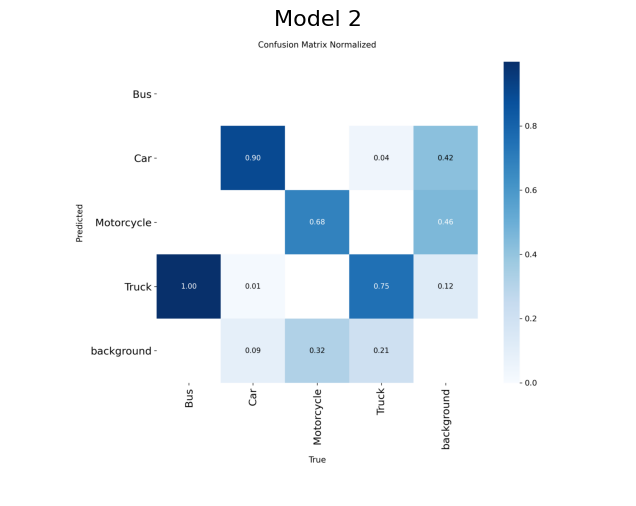

In [15]:
#The line below defines a variable that holds the file location of the second confusion matrix.
#This image is produced by YOLO after completing the second training run.
img_path2 = '/content/runs/detect/train2/confusion_matrix_normalized.png'

#The line below reads the image from disk and converts it into an array format.
#This prepares the image so it can be visualized using matplotlib.
img2 = mpimg.imread(img_path2)

#The line below creates a new plotting figure.
#The figure size is specified to control how large the visualization appears.
plt.figure(figsize=(8,6))

#The line below displays the loaded image inside the plot.
#This renders the confusion matrix for viewing.
plt.imshow(img2)

#The line below removes the axis ticks and labels from the figure.
#This keeps the focus on the confusion matrix itself.
plt.axis('off')

#The line below adds a descriptive title to the visualization.
#It indicates that the displayed confusion matrix corresponds to Model 2.
plt.title('Model 2', fontsize=16)

#The line below renders the final plot to the output.
#This shows the confusion matrix generated for the second model.
plt.show()

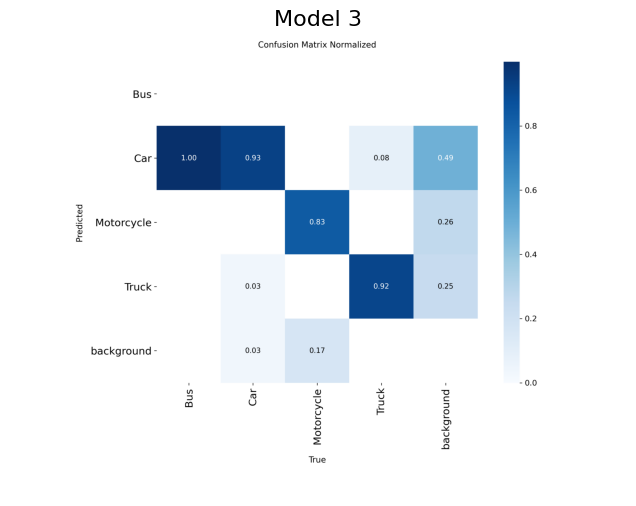

In [16]:
#The line below stores the file path for the third confusion matrix image.
#This file is automatically generated by YOLO after training the third model.
img_path3 = '/content/runs/detect/train3/confusion_matrix_normalized.png'

#The line below loads the image and converts it into an array structure.
#This allows matplotlib to properly render the image in a plot.
img3 = mpimg.imread(img_path3)

#The line below initializes a new figure for plotting.
#We specify the figure dimensions to control the display size.
plt.figure(figsize=(8,6))

#The line below draws the loaded confusion matrix onto the figure.
#This makes the visualization visible within the plot.
plt.imshow(img3)

#The line below removes the axis lines and tick labels.
#This keeps the output visually clean and focused on the matrix.
plt.axis('off')

#The line below sets the title of the plot.
#It labels the visualization as belonging to Model 3.
plt.title('Model 3', fontsize=16)

#The line below renders the figure to the screen.
#This displays the confusion matrix associated with the third model.
plt.show()

In [17]:
#The command below runs a shell operation to copy files from the Colab environment.
#It creates a backup of the training outputs by transferring the runs folder to Google Drive.
!cp -r /content/runs /content/drive/MyDrive/

# Discussion & Analysis

During this workflow, I began by preparing the environment and importing the required libraries for visualization, data handling, and model execution. Mounting Google Drive ensured that the dataset and training outputs could be accessed and preserved across sessions. After installing the Ultralytics package, I initialized three separate YOLOv26n model instances. Although they share the same base architecture, each model was configured with different hyperparameters to observe how training behavior and detection performance would vary under different optimization strategies.

The training phase is where the models learn meaningful patterns from the labeled dataset. Each model iteratively processed the images and annotations defined in the data.yaml file. Model 1 was trained with AdamW and a moderate learning rate, which typically promotes stable convergence. Model 2 used SGD with a larger batch size and more epochs, encouraging more traditional gradient-based optimization that can generalize well on larger datasets. Model 3 relied on YOLO’s automatic optimizer selection with the smallest learning rate and auto batch sizing, allowing the framework to dynamically adjust resource usage and optimization behavior. Across epochs, the models updated their weights to minimize detection loss, gradually improving their ability to localize and classify objects.

After training, I executed the validation phase for each model to measure generalization performance on unseen data. The returned metrics—mAP50, precision, recall, and the derived F1 score—quantify different aspects of detection quality. Precision reflects how accurate the predicted detections are, recall measures how many true objects were successfully found, and mAP50 summarizes localization and classification performance at the IoU threshold of 0.50. The F1 score provides a balanced single-value indicator of overall detection effectiveness. By organizing these metrics into a comparison table, I can clearly observe which hyperparameter configuration yields the strongest performance.

To further interpret model behavior, I visualized the normalized confusion matrices generated by YOLO. These plots reveal how well each model distinguishes between classes and where misclassifications occur. Strong diagonal values indicate correct predictions, while off-diagonal values highlight confusion between classes. This visual diagnostic is important because numerical metrics alone may hide class-specific weaknesses.

Finally, I backed up the entire runs directory to Google Drive to preserve trained weights, logs, and visual outputs. Overall, the pipeline demonstrates a controlled experimental comparison of three YOLOv26 configurations, allowing me to analyze how optimizer choice, batch size, learning rate, and training duration influence object detection performance.

# References

Ultralytics. (2024). Ultralytics YOLO documentation.
https://docs.ultralytics.com/

Redmon, J., Divvala, S., Girshick, R., & Farhadi, A. (2016). You only look once: Unified, real-time object detection. Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition (CVPR).
https://arxiv.org/abs/1506.02640

Paszke, A., Gross, S., Massa, F., et al. (2019). PyTorch: An imperative style, high-performance deep learning library. Advances in Neural Information Processing Systems, 32.
https://arxiv.org/abs/1912.01703

McKinney, W. (2010). Data structures for statistical computing in Python. Proceedings of the 9th Python in Science Conference.
https://pandas.pydata.org/docs/

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. Computing in Science & Engineering, 9(3), 90–95.
https://matplotlib.org/stable/index.html